In [1]:
from MITgcmutils.utils import writebin
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from mitkit.ocean.utils import *
from mitkit.paths import project_root
from pathlib import Path

xrg = 180
yrg = 48
RES = 4
dx = 1/RES     # grid spacing in x (degrees longitude)
dy = 1/RES     # grid spacing in y (degrees latitude)
nx, ny = int(xrg//dx), int(yrg//dy)   # gridpoints in x

print('Nx,Ny=',nx,ny)

x0 = 112     # origin in x,y for ocean domain
y0 = -23.5    # (i.e. southwestern corner of ocean domain)
x1 = x0 + (nx-1)*dx    # origin in x,y for ocean domain
y1 = y0 + (ny-1)*dy    # (i.e. southwestern corner of ocean domain)

opath = str(project_root() / 'input') + '/' 

# ipath = '/mnt/d/project/IAVNNG/Data/'
# ipath = '../../IAVNNG/data/'
ipath = str(Path.home() / 'data') + '/' 
# input files
fbath = ipath + 'GLO-MFC_001_030_mask_bathy.nc'
fcoor = ipath + 'GLO-MFC_001_030_coordinates.nc'
fclim = ipath + 'cmems_climatology_mon.nc'
fsflux = ipath + 'era5_surfflux_mon.nc'
fsvar = ipath + 'era5_surfvar_mon.nc'
fwlsm = ipath + 'era5_lsm.nc'

inc = round(dx*12)
winc = round(dx*4)

Nx,Ny= 720 192


## 生成海表面强迫场（标量形式：风速、温度、降水，下行辐射，Agrid）

In [ ]:
do_clim = False # 是否气候态
do_smooth = False  # 是否平滑
wedge = 3

# 时间和空间切片
tsl = slice('1940-01', None)
yisl = slice(y0-wedge,y1+wedge,-1)
xisl = slice(x0-wedge,x1+wedge)
yosl = slice(y0, y1, winc)
xosl = slice(x0, x1, winc)
lsm  = xr.open_dataset(fwlsm)['lsm'].loc[yisl,xisl].values<0.5

ds = xr.open_dataset(fsvar).sel(valid_time=tsl,latitude=yisl,longitude=xisl)

var_names = ['u10','v10','t2m','sh2m','avg_tprate','avg_sdswrf','avg_sdlwrf']
# 存储处理后数据的字典
result = {}
for var in var_names:
    data = ds[var].load()
    # 如果需要气候态（月平均）
    if do_clim:
        data = data.groupby('valid_time.month').mean('valid_time')
    # 统一空间平滑（如果开启）
    if do_smooth:
        data.values = gsmooth2d(data.values,sigma=winc / 3,mask=lsm,threshold=0.1,fill_value=0)
    # 最终裁剪到目标区域
    data = data.loc[:, yosl, xosl]
    # 转为 numpy 数组并存入字典
    result[var] = data.values
    print(f"{var} shape: {result[var].shape}")

wspeed = np.sqrt(result['u10']**2 + result['v10']**2) # 风速（用于计算感热、潜热和蒸发）
aqh = result['sh2m']  # 比湿
swdown = result['avg_sdswrf']  # 单独的短波辐射通量
lwdown = result['avg_sdlwrf']  # 下行长波辐射
precip = result['avg_tprate']/1e3 # 单位转换,mit以淡水流失为正（era5的以淡水输入为正）

# 保存为MITgcm驱动所需的二进制文件
writebin(opath+'exf_uwind.bin',result['u10'])
writebin(opath+'exf_vwind.bin',result['v10'])
writebin(opath+'exf_wspeed.bin',wspeed)
writebin(opath+'exf_atemp.bin',result['t2m'])
writebin(opath+'exf_aqh.bin', aqh)
writebin(opath+'exf_swdown.bin',swdown)
writebin(opath+'exf_lwdown.bin',lwdown)
writebin(opath+'exf_precip.bin',precip)


u10 shape: (12, 192, 720)
v10 shape: (12, 192, 720)
t2m shape: (12, 192, 720)
sh2m shape: (12, 192, 720)
avg_tprate shape: (12, 192, 720)
avg_sdswrf shape: (12, 192, 720)
avg_sdlwrf shape: (12, 192, 720)


## 生成海表面强迫场（标量形式：风应力，Cgrid）

In [ ]:
yisl = slice(y0-wedge,y1+wedge,-1)
xisl = slice(x0-wedge,x1+wedge)
yosl = slice(y0, y1, winc)
xosl = slice(x0, x1, winc)
lsm  = xr.open_dataset(fwlsm)['lsm'].loc[yisl,xisl].values<0.5

ds = xr.open_dataset(fsflux).sel(valid_time=tsl,latitude=yisl,longitude=xisl)

# var_names = ['iews','inss','ie','tprate','slhtf','ishf','snlwrf','snswrf']
var_names = ['iews','inss']
# 存储处理后数据的字典
result = {}
for var in var_names:
    data = ds['avg_' + var].load()
    # 如果需要气候态（月平均）
    if do_clim:
        data = data.groupby('valid_time.month').mean('valid_time')
    # 统一空间平滑（如果开启）
    if do_smooth:
        data.values = gsmooth2d(data.values,sigma=winc / 3,mask=lsm,threshold=0.1,fill_value=0)
    # 最终裁剪到目标区域
    data = data.loc[:, yosl, xosl]
    # 转为 numpy 数组并存入字典
    result[var] = data.values
    print(f"{var} shape: {data.values.shape}")

uflux = result['iews']
vflux = result['inss']
# hflux = -(result['slhtf'] + result['ishf'] + result['snlwrf'] + result['snswrf']) # mit以热输出为正（era5的以热输入为正）
# swflux = -result['snswrf']  # 单独的短波辐射通量
# sflux = -(result['ie'] + result['tprate'])/1e3 # 单位转换,mit以淡水流失为正（era5的以淡水输入为正）
# 保存为MITgcm驱动所需的二进制文件
writebin(opath+'exf_ustress.bin',uflux)
writebin(opath+'exf_vstress.bin',vflux)
# writebin(opath+'exf_hflux.bin',hflux)
# writebin(opath+'exf_swflux.bin', swflux)
# writebin(opath+'exf_sflux.bin',sflux)

iews shape: (1030, 192, 720)
inss shape: (1030, 192, 720)


## 生成地形数据
---
需注意水深取负值，且将陆地填补为0

(601, 2401) (192, 720) 24.25


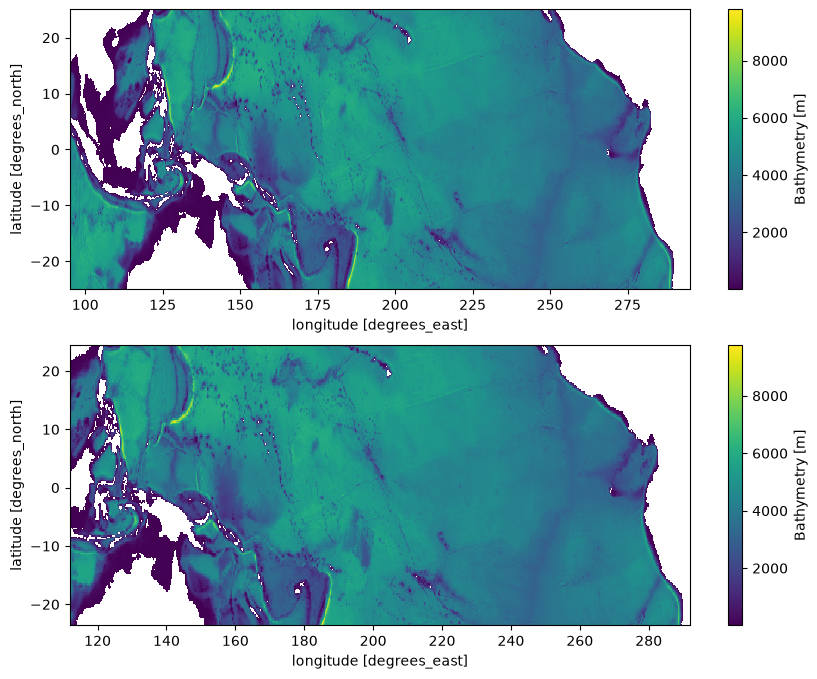

In [2]:
import matplotlib.pyplot as plt
import heapq
import numpy as np

xll,xrr = 95,295
yd,yu = -25,25
pts_l = [[121.51,yu],[143,yd]]
pts_r = [[260,yu],[290,yd]]
with xr.open_dataset(fbath) as ds:
    da = ds['deptho']
    hl = da.loc[yd:yu,xll:xrr]
    hr = da.loc[yd:yu,xll-360:xrr-360]
    hr['longitude'] = hr['longitude'] + 360
ho = xr.concat([hl,hr],dim='longitude')
col = ho.indexes['longitude'].get_indexer(list(zip(*pts_l))[0],method='nearest')
row = ho.indexes['latitude'].get_indexer(list(zip(*pts_l))[1],method='nearest')
ind_l = list(zip(row,col))
col = ho.indexes['longitude'].get_indexer(list(zip(*pts_r))[0],method='nearest')
row = ho.indexes['latitude'].get_indexer(list(zip(*pts_r))[1],method='nearest')
ind_r = list(zip(row,col))
wm = ho.values.copy()
wm += 100
wm[np.isnan(wm)] = 0
wm += 200

path_l,_ = astar_2d(wm,*ind_l)
path_r,_ = astar_2d(wm,*ind_r)

# 根据路径设置水深为np.nan
h_arr = ho.values.copy()
# 西侧覆盖
# for r, c in path_l:
#     h_arr[r, c] = np.nan
# 东侧覆盖
for r, c in path_r:
    h_arr[r, c] = np.nan
mask_ho = ~largest_connected_region(~np.isnan(h_arr))
ho.values[mask_ho] = np.nan
ho.values = gsmooth2d(ho.values,sigma=inc/3, norm=False)
h = ho.loc[y0:y1:inc,x0:x1:inc]

plt.figure(figsize=(10,8))
plt.subplot(211)
ho.plot()
# 可视化结果
plt.subplot(212)
h.plot()

h = h.values.copy()
h[np.isnan(h)] = 0
h = -h
print(ho.shape,h.shape,y1)
writebin(opath+'bathy_gsm.bin',h)
# h1 = np.fromfile('../input/bathy.bin',dtype='>f4').reshape(h.shape)

## 基于再分析气候态数据 生成边界条件

### 分割垂向网格

In [3]:
import xarray as xr
# new vertical grid
ds = xr.open_dataset(fcoor)
dr = ds['e3t'].values
Rid = [0,4,7,10,12]+[id for id in range(14,dr.size)]
# Rid = [0,5,9,12,14]+[id for id in range(16,dr.size)]

dR = np.zeros(len(Rid)-1)
for i in range(len(Rid)-1):
    dR[i] = dr[Rid[i]:Rid[i+1]].sum()
nz = len(dR)
print('Nr  = {:4d}'.format(len(dR)))
print('H   =',dR.sum())
print(' delR=', end='')
for i, x in enumerate(dR):
    if i % 10 == 0 and i > 0:
        print()  # New line after every 10 values
        print('      ', end='')  # Add 5 spaces for indentation
    print(f"{x:6.2f},", end='')
print()  # Final newline

Nr  =   40
H   = 5499.565798282623
 delR=  4.45,  4.29,  5.86,  5.38,  7.24,  4.59,  5.42,  6.43,  7.67,  9.16,
       10.98, 13.18, 15.85, 19.06, 22.93, 27.58, 33.14, 39.75, 47.59, 56.83,
       67.62, 80.13, 94.49,110.79,129.07,149.26,171.22,194.71,219.37,244.78,
      270.44,295.85,320.51,344.00,365.96,386.15,404.42,420.73,435.09,447.60,


### 生成温盐流初始场

In [9]:
ds = xr.open_dataset(fclim)

var_names = ['uo','vo','thetao','so']
# 存储处理后数据的字典
result = {}
for var in var_names:
    # 一月气候态平均作为初始场
    data = ds[var][[0, 11]].mean("time")
    data.values[:,mask_ho] = np.nan
    data.values = gsmooth2d(data.values,sigma=inc/3,threshold=0.1)
    data = data.loc[:,y0:y1:inc,x0:x1:inc]
    data = data.values
    for i in range(data.shape[0]):
        data[i] = fillna(data[i])
    datai = np.zeros((nz,ny,nx))
    for i in range(nz):
        datai[i] = (data[Rid[i]:Rid[i+1]]*dr[Rid[i]:Rid[i+1],None,None]).sum(0)/dR[i,None,None]
    result[var] = datai

# 特殊处理海面高度
var = 'zos'
var_names.append(var)
data = ds[var][0].load()
data.values[mask_ho] = np.nan
data.values = gsmooth2d(data.values,sigma=inc/3,threshold=0.1)
data = data.loc[y0:y1:inc,x0:x1:inc]
data = fillna(data.values)
result[var] = data

for var in var_names:
    print(f"{var} shape: {result[var].shape}")
    writebin(opath+f'init/{var}_{RES}_{nz}.bin',result[var])


uo shape: (40, 192, 720)
vo shape: (40, 192, 720)
thetao shape: (40, 192, 720)
so shape: (40, 192, 720)
zos shape: (192, 720)


### 生成侧边界条件

In [6]:
# 生成温盐流侧边界（T/S/U/V）
bd = 1
obcs = ['S','N','W']
varname = ['thetao','so','uo','vo']
xsi_map = {'W': slice(x0-bd, x0+bd), 'E': slice(x1-bd, x1+bd)}
ysi_map = {'S': slice(y0-bd, y0+bd), 'N': slice(y1-bd, y1+bd)}
xso_map = {'W': x0,'E': x1}
yso_map = {'S': y0,'N': y1}

ds = xr.open_dataset(fclim)
for obc in obcs:
    print(f'处理{obc}边界')
    xsi = xsi_map.get(obc, slice(None))
    ysi = ysi_map.get(obc, slice(None))
    xso = xso_map.get(obc, slice(x0,x1,inc))
    yso = yso_map.get(obc, slice(y0,y1,inc))
    for vn in varname:
        arr = ds[vn].loc[:,:,ysi,xsi].load()
        # 掩膜obs
        mask = np.isnan(ho.loc[ysi,xsi].values)
        arr.values[:,:, mask] = np.nan
        # 平滑
        arr.values = gsmooth2d(arr.values, sigma=inc/3, threshold=0.1)
        # 插值到目标网格
        arr = arr.loc[:, :, yso, xso]
        arr = arr.values
        # 填充缺失值
        for i in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                arr[i,j] = fillna(arr[i,j])
        # 垂向加权平均（T/S/U/V都处理）
        arr_new = np.zeros((arr.shape[0],nz, arr.shape[2]))
        for k in range(nz):
            arr_new[:,k] = (arr[:,Rid[k]:Rid[k+1]]*dr[Rid[k]:Rid[k+1],None]).sum(1)/dR[k,None]
        print(f'{obc}_{vn[0].upper()} shape:', arr_new.shape)
        writebin(f"{opath}obcs/OB{obc}{vn[0]}_{RES}_{nz}.bin", arr_new)

处理S边界
S_T shape: (12, 40, 720)
S_S shape: (12, 40, 720)
S_U shape: (12, 40, 720)
S_V shape: (12, 40, 720)
处理N边界
N_T shape: (12, 40, 720)
N_S shape: (12, 40, 720)
N_U shape: (12, 40, 720)
N_V shape: (12, 40, 720)
处理W边界
W_T shape: (12, 40, 192)
W_S shape: (12, 40, 192)
W_U shape: (12, 40, 192)
W_V shape: (12, 40, 192)
